# Edited-Span Vector Analysis
Extract the surface-form vector using only the first line of each reasoning trace (no final answer included).

## 1. Configuration
Update paths or layer selections as needed.

In [1]:
from pathlib import Path

import os, sys
os.chdir('..')
sys.path.append(os.getcwd())
print('Working directory:', os.getcwd())

DATASET_PATH = Path("data/on_policy_persona.json")
MODEL_NAME = "Qwen/Qwen3-4B"
LAYERS = None  # e.g. [18, 19, 20]
REDUCTION = "mean"
SAVE_DIR = Path("artifacts/edited_span_runs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

Working directory: /Users/lr/policy_vector/shareable


## 2. Generate and save truncated dataset

In [2]:
from policy_vector_pipeline import (
    load_dataset,
    save_dataset,
    OnPolicyDataset,
    ReasoningExample,
    ResponseVariant,
)

print(f"Loading dataset from {DATASET_PATH}")
dataset = load_dataset(DATASET_PATH)
print(f"Loaded {len(dataset)} examples")

# Truncate to first line only
def _first_reasoning_line(reasoning: str) -> str:
    text = reasoning or ""
    if "<think>" in text:
        _, rest = text.split("<think>", 1)
        body = rest.split("</think>", 1)[0]
        for line in body.splitlines():
            stripped = line.strip()
            if stripped:
                return "<think>\n" + stripped
        return "<think>"
    for line in text.splitlines():
        stripped = line.strip()
        if stripped:
            return stripped
    return ""

examples = []
for ex in dataset.examples:
    on_variants = [
        ResponseVariant(
            reasoning=_first_reasoning_line(variant.reasoning),
            final_answer=variant.final_answer,
            metadata=variant.metadata,
        )
        for variant in ex.on_policy
    ]
    off_variants = [
        ResponseVariant(
            reasoning=_first_reasoning_line(variant.reasoning),
            final_answer=variant.final_answer,
            metadata=variant.metadata,
        )
        for variant in ex.off_policy
    ]
    examples.append(
        ReasoningExample(
            example_id=f"{ex.example_id}-first-line",
            prompt=ex.prompt,
            on_policy=on_variants,
            off_policy=off_variants,
            correct_answer=ex.correct_answer,
            metadata={**ex.metadata, "trimmed": "first_line"},
            similarity=ex.similarity,
        )
    )

truncated_dataset = OnPolicyDataset(examples=examples, metadata={**dataset.metadata, "trimmed": "first_line"})
print(f"Truncated to first line: {len(truncated_dataset)} examples")

# Save for verification
FIRST_LINE_PATH = Path("data/on_policy_first_line.json")
save_dataset(truncated_dataset, FIRST_LINE_PATH)
print(f"Saved to {FIRST_LINE_PATH}")

Loading dataset from data/on_policy_persona.json
Loaded 60 examples
Truncated to first line: 60 examples
Saved to data/on_policy_first_line.json


## 3. Load truncated dataset and model

In [3]:
from policy_vector_pipeline import (
    ActivationCollector,
    MeanDifferenceVector,
    load_model_and_tokenizer,
)
from scripts.evaluate_vector import compute_stats

# Load the truncated dataset
dataset = load_dataset(FIRST_LINE_PATH)
print(f"Loaded {len(dataset)} examples from {FIRST_LINE_PATH}")

# Load model
model, tokenizer = load_model_and_tokenizer(MODEL_NAME, device_map="auto", dtype="auto")
print(f"Model loaded")

Loaded 60 examples from data/on_policy_first_line.json


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Model loaded


## 4. Collect activations

In [4]:
collector = ActivationCollector(model, tokenizer, layers=LAYERS, reduction=REDUCTION, response_only=True, include_answer=False)
activations = collector.collect_dataset(dataset, progress=True)
print("Collected activations (reasoning only, no final answer)")

Collected activations (reasoning only, no final answer)


## 5. Build vector and view stats

In [5]:
vector = MeanDifferenceVector.from_activations(activations["on"], activations["off"])
stats = compute_stats(activations, vector)

from pprint import pprint
print("Top 5 layers (first line only):")
pprint(stats[:5])

Top 5 layers (first line only):
[{'cohens_d': 4.439579404710888,
  'diff': 16.98704481124878,
  'layer': 24,
  'mean_off': -5.13834810256958,
  'mean_on': 11.8486967086792,
  'off_acc': 0.9484536051750183,
  'on_acc': 1.0,
  'overall_acc': 0.9742268025875092,
  'std_off': 4.950128557481684,
  'std_on': 2.1856266174223156,
  'threshold': 3.3551743030548096},
 {'cohens_d': 4.42089793611374,
  'diff': 18.825289726257324,
  'layer': 25,
  'mean_off': -5.364482879638672,
  'mean_on': 13.460806846618652,
  'off_acc': 0.9484536051750183,
  'on_acc': 1.0,
  'overall_acc': 0.9742268025875092,
  'std_off': 5.4524799828946815,
  'std_on': 2.556531048459905,
  'threshold': 4.04816198348999},
 {'cohens_d': 4.329635500485237,
  'diff': 22.294421195983887,
  'layer': 26,
  'mean_off': -13.7652006149292,
  'mean_on': 8.529220581054688,
  'off_acc': 0.9553264379501343,
  'on_acc': 1.0,
  'overall_acc': 0.9776632189750671,
  'std_off': 6.560398019485728,
  'std_on': 3.16084529121833,
  'threshold': -2.6

## 6. (Optional) save vector

In [6]:
vector_path = SAVE_DIR / "vector_first_line.pt"
vector.save(vector_path)
print(f"Saved first-line vector to {vector_path}")

Saved first-line vector to artifacts/edited_span_runs/vector_first_line.pt


## 7. (Optional) plot projection histogram

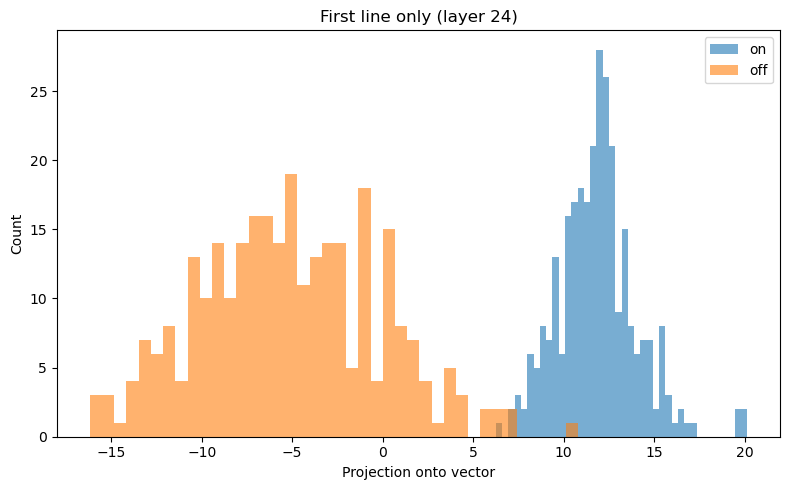

In [7]:
import matplotlib.pyplot as plt
import torch

best_layer = stats[0]["layer"]
vec = vector.layer_vectors[best_layer].to(torch.float32)
vec = vec / (torch.linalg.norm(vec) + 1e-8)

proj_on = torch.stack([a.to(torch.float32) for a in activations["on"][best_layer]]) @ vec
proj_off = torch.stack([a.to(torch.float32) for a in activations["off"][best_layer]]) @ vec

plt.figure(figsize=(8, 5))
plt.hist(proj_on.cpu().numpy(), bins=40, alpha=0.6, label="on")
plt.hist(proj_off.cpu().numpy(), bins=40, alpha=0.6, label="off")
plt.title(f"First line only (layer {best_layer})")
plt.xlabel("Projection onto vector")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()